In [1]:
import os
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
models = pd.read_csv("pretrained_models_openclip_full.csv")

In [3]:
models

,model_name,dataset
0,RN50,openai
1,RN50,yfcc15m
2,RN50,cc12m
3,RN101,openai
4,RN101,yfcc15m
...,...,...
191,ViT-H-14-quickgelu,metaclip_fullcc
192,ViT-H-14-quickgelu,dfn5b
193,ViT-H-14-378-quickgelu,dfn5b
194,ViT-bigG-14-quickgelu,metaclip_fullcc


In [4]:
for a in models.itertuples():
    break
a

Pandas(Index=0, model_name='RN50', dataset='openai')

In [30]:
results_folders = np.array(glob("Results/*/mahalanobis_best.csv"))
results_names = np.array([r.split("/")[1] for r in results_folders])
ratios = {}
for names in models.itertuples():
    name = "-".join([names.model_name, names.dataset])
    if name in results_names:
        path = results_folders[name==results_names].item()
        df = pd.read_csv(path)
        model_name = path.split("/")[1]
        pass_ratio = df["pass"].mean()
        ratios["/".join([names.model_name, names.dataset])] = pass_ratio

In [31]:
ratios

{'RN50/openai': 0.81,
 'RN50/yfcc15m': 0.5,
 'RN50/cc12m': 0.57,
 'RN101/openai': 0.74,
 'RN101/yfcc15m': 0.56,
 'RN50x4/openai': 0.71,
 'RN50x16/openai': 0.78,
 'RN50x64/openai': 0.72,
 'ViT-B-32/openai': 0.85,
 'ViT-B-32/laion400m_e31': 0.78,
 'ViT-B-32/laion400m_e32': 0.83,
 'ViT-B-32/laion2b_e16': 0.76,
 'ViT-B-32/laion2b_s34b_b79k': 0.77,
 'ViT-B-32/datacomp_xl_s13b_b90k': 0.9,
 'ViT-B-32/datacomp_m_s128m_b4k': 0.75,
 'ViT-B-32/commonpool_m_clip_s128m_b4k': 0.82,
 'ViT-B-32/commonpool_m_laion_s128m_b4k': 0.78,
 'ViT-B-32/commonpool_m_image_s128m_b4k': 0.82,
 'ViT-B-32/commonpool_m_text_s128m_b4k': 0.71,
 'ViT-B-32/commonpool_m_basic_s128m_b4k': 0.76,
 'ViT-B-32/commonpool_m_s128m_b4k': 0.79,
 'ViT-B-32/datacomp_s_s13m_b4k': 0.79,
 'ViT-B-32/commonpool_s_clip_s13m_b4k': 0.78,
 'ViT-B-32/commonpool_s_laion_s13m_b4k': 0.62,
 'ViT-B-32/commonpool_s_image_s13m_b4k': 0.79,
 'ViT-B-32/commonpool_s_text_s13m_b4k': 0.73,
 'ViT-B-32/commonpool_s_basic_s13m_b4k': 0.72,
 'ViT-B-32/commonpool_

In [32]:
ratios = pd.DataFrame({k:[v] for k,v in ratios.items()}).T

In [33]:
ratios = ratios.reset_index(names="model-dst")
ratios = ratios.rename({0: "ratio"}, axis=1)
ratios.head()

,model-dst,ratio
0,RN50/openai,0.81
1,RN50/yfcc15m,0.50
2,RN50/cc12m,0.57
3,RN101/openai,0.74
4,RN101/yfcc15m,0.56


In [34]:
ratios["model"] = ratios["model-dst"].apply(lambda x: x.split("/")[0])
ratios["dataset"] = ratios["model-dst"].apply(lambda x: x.split("/")[1])
ratios = ratios[["model-dst", "model", "dataset", "ratio"]]

In [35]:
ratios

,model-dst,model,dataset,ratio
0,RN50/openai,RN50,openai,0.81
1,RN50/yfcc15m,RN50,yfcc15m,0.50
2,RN50/cc12m,RN50,cc12m,0.57
3,RN101/openai,RN101,openai,0.74
4,RN101/yfcc15m,RN101,yfcc15m,0.56
...,...,...,...,...
157,PE-Core-L-14-336/meta,PE-Core-L-14-336,meta,0.70
158,ViT-H-14-worldwide/metaclip2_worldwide,ViT-H-14-worldwide,metaclip2_worldwide,0.75
159,ViT-H-14-worldwide-378/metaclip2_worldwide,ViT-H-14-worldwide-378,metaclip2_worldwide,0.77
160,ViT-bigG-14-worldwide/metaclip2_worldwide,ViT-bigG-14-worldwide,metaclip2_worldwide,0.64


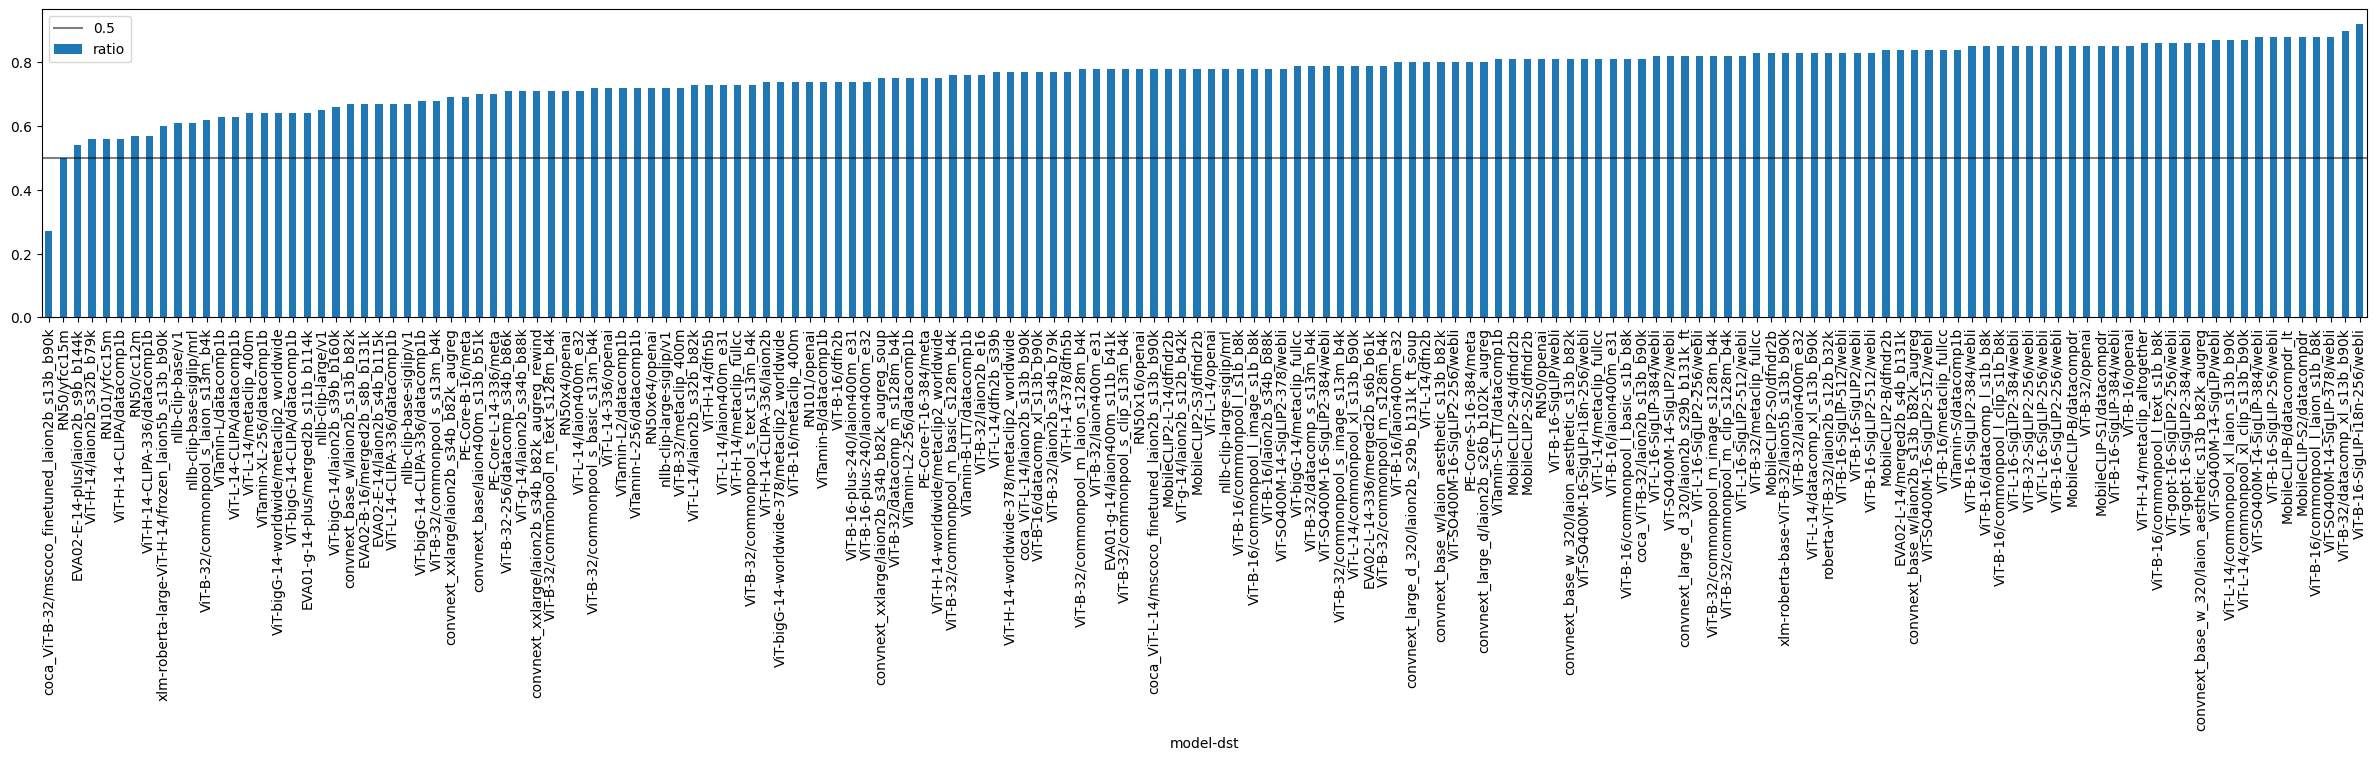

In [44]:
ratios.sort_values("ratio").plot(x="model-dst", y="ratio", kind="bar", figsize=(30,4))
plt.axhline(0.5, color="black", alpha=0.5, label="0.5")
plt.legend()
plt.show()

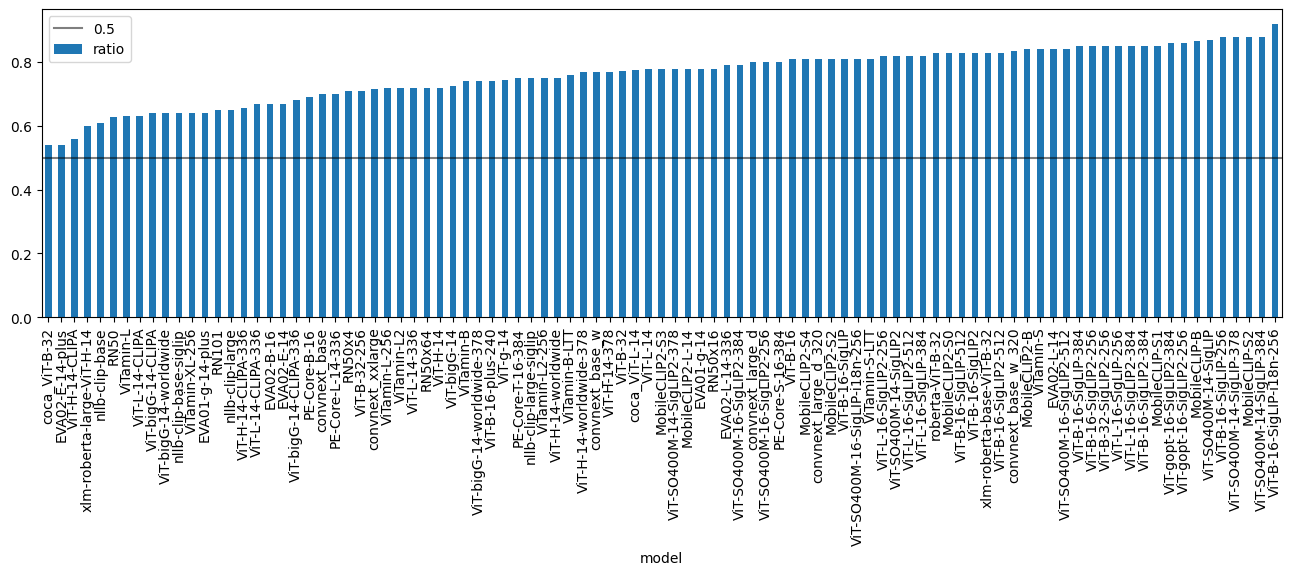

In [45]:
ratios.groupby("model")["ratio"].mean().sort_values().plot(x="model-dst", y="ratio", kind="bar", figsize=(16,4))
plt.axhline(0.5, color="black", alpha=0.5, label="0.5")
plt.legend()
plt.show()

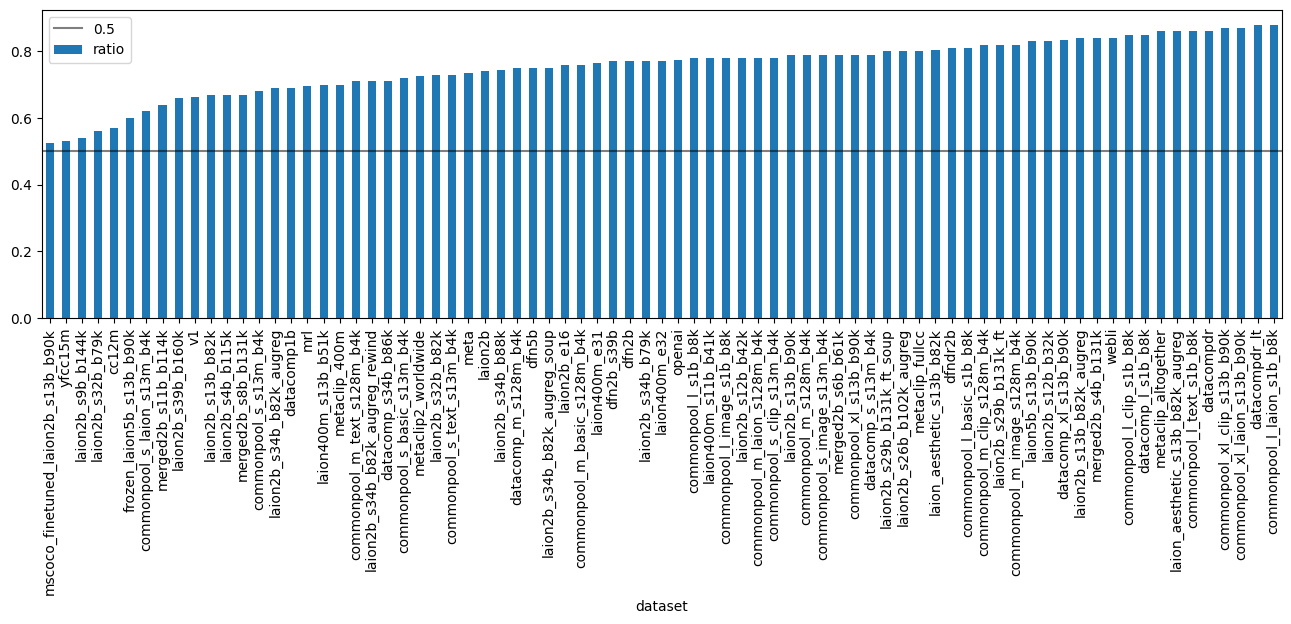

In [46]:
ratios.groupby("dataset")["ratio"].mean().sort_values().plot(x="model-dst", y="ratio", kind="bar", figsize=(16,4))
plt.axhline(0.5, color="black", alpha=0.5, label="0.5")
plt.legend()
plt.show()